In [1]:
from google.colab import files
uploaded = files.upload()

Saving newsimages_test_and_evaluation_26_v1.0.zip to newsimages_test_and_evaluation_26_v1.0.zip


In [2]:
import zipfile
with zipfile.ZipFile("newsimages_test_and_evaluation_26_v1.0.zip", 'r') as zip_ref:
    zip_ref.extractall("news_images")

In [3]:
import os
import pandas as pd
from transformers import Blip2Processor, Blip2ForConditionalGeneration
import torch
from PIL import Image
from tqdm import tqdm
import torch

In [4]:
df = pd.read_csv("/content/news_images/newsimages_test_and_evaluation_26_v1.0/news_articles_evaluation.csv",encoding="latin-1")
df.head()

,article_id,article_url,article_title,image_id
0,8503,https://resolver.kb.nl/resolve?urn=MMSAA06:165...,HH's visit MM. the queens at the Onze Lieve Vr...,ecebad66d2b4fd4e7bbb2b97d57bb100
1,8502,https://resolver.kb.nl/resolve?urn=MMSAA06:165...,The demise of 'Burgundy'.,3d446f6d460b6c80ed8bb7eed7a608f3
2,8506,https://resolver.kb.nl/resolve?urn=MMRHCE02:16...,Moscow against 'free airspace' KROESJEF DOES N...,fe269637ca212eaba179461c6e6570fa
3,8507,https://resolver.kb.nl/resolve?urn=MMRHCE02:16...,Situation in South Africa still tense DEATH TO...,93ad24f5fd48351a74dfe1ac691fdf20
4,8505,https://resolver.kb.nl/resolve?urn=MMRHCE02:16...,Three Thunderstreaks crashed over Gelderland. ...,92c89d592e630ab686e72a8c3b96226e


In [5]:
image_folder = "/content/news_images/newsimages_test_and_evaluation_26_v1.0/news_images_evaluation"
def get_image_path(image_id):
    return os.path.join(image_folder, f"{image_id}.jpg")
df["image_path"] = df["image_id"].apply(get_image_path)
df.head()

,article_id,article_url,article_title,image_id,image_path
0,8503,https://resolver.kb.nl/resolve?urn=MMSAA06:165...,HH's visit MM. the queens at the Onze Lieve Vr...,ecebad66d2b4fd4e7bbb2b97d57bb100,/content/news_images/newsimages_test_and_evalu...
1,8502,https://resolver.kb.nl/resolve?urn=MMSAA06:165...,The demise of 'Burgundy'.,3d446f6d460b6c80ed8bb7eed7a608f3,/content/news_images/newsimages_test_and_evalu...
2,8506,https://resolver.kb.nl/resolve?urn=MMRHCE02:16...,Moscow against 'free airspace' KROESJEF DOES N...,fe269637ca212eaba179461c6e6570fa,/content/news_images/newsimages_test_and_evalu...
3,8507,https://resolver.kb.nl/resolve?urn=MMRHCE02:16...,Situation in South Africa still tense DEATH TO...,93ad24f5fd48351a74dfe1ac691fdf20,/content/news_images/newsimages_test_and_evalu...
4,8505,https://resolver.kb.nl/resolve?urn=MMRHCE02:16...,Three Thunderstreaks crashed over Gelderland. ...,92c89d592e630ab686e72a8c3b96226e,/content/news_images/newsimages_test_and_evalu...


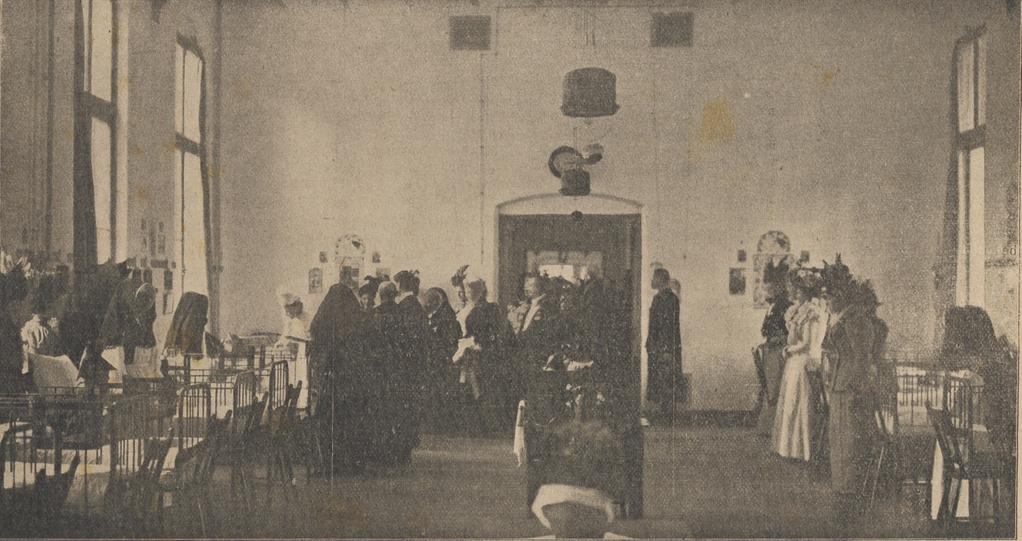

In [6]:
from PIL import Image
img = Image.open(df["image_path"].iloc[0])
img

In [7]:
device = "mps" if torch.accelerator.is_available() else "cpu"
print(device)
processor = Blip2Processor.from_pretrained("Salesforce/blip2-opt-2.7b")

model = Blip2ForConditionalGeneration.from_pretrained(
    "Salesforce/blip2-opt-2.7b",
    torch_dtype=torch.float16,
    device_map="auto"
)

mps


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/432 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

In [8]:
def generate_caption(img_path):
    try:
        image = Image.open(img_path).convert("RGB")
        inputs = processor(
            images=image,
            return_tensors="pt"
        )
        inputs = {k: v.to(model.device) for k, v in inputs.items()}
        with torch.no_grad():
            generated_ids = model.generate(
                **inputs,
                max_new_tokens=50,
                num_beams=5,
                temperature=0.7
            )
        caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        caption = caption.replace("a photo of", "").strip()
        return caption
    except Exception as e:
        print(f"Error with {img_path}: {e}")
        return ""

In [9]:
tqdm.pandas()
df["caption"] = df["image_path"].progress_apply(generate_caption)
df.to_csv("evaluation_with_captions.csv", index=False)
print("Done! CSV updated with captions.")

100%|██████████| 14380/14380 [2:45:49<00:00,  1.45it/s]

Done! CSV updated with captions.
